In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import logging

import mlflow
from mlflow.data.pandas_dataset import from_pandas
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

from chesswinnerprediction.baseline.models.naive_model import NaiveModel
from chesswinnerprediction.baseline.utils import (
    estimate_baseline_model,
    get_x_and_y,
    get_class_weights,
    transform_and_scale_df,
)
from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE
from chesswinnerprediction.constants import DRAW_STR, PROCESSED_FOLDER_PATH
from config import BASELINE_EXPERIMENT, MLRUNS_FOLDER_PATH

## MLFlow Configuration

In [3]:
mlflow.set_tracking_uri(MLRUNS_FOLDER_PATH)

In [4]:
mlflow.set_experiment(experiment_name=BASELINE_EXPERIMENT)
mlflow.sklearn.autolog(log_post_training_metrics=True)

In [5]:
mlflow_logger = logging.getLogger("mlflow")
mlflow_logger.setLevel(logging.ERROR)

## Data Preparation

In [6]:
data_dir = "lichess_db_standard_rated_2017-05"
data_path = os.path.join(PROCESSED_FOLDER_PATH, data_dir)

In [7]:
train_df = pd.read_csv(os.path.join(data_path, "train.csv"))
valid_df = pd.read_csv(os.path.join(data_path, "valid.csv"))
test_df = pd.read_csv(os.path.join(data_path, "test.csv"))

In [8]:
std_scaler = StandardScaler()
train_data = transform_and_scale_df(train_df, std_scaler)
valid_data = transform_and_scale_df(valid_df, std_scaler, fit_scaler=False)
test_data = transform_and_scale_df(test_df, std_scaler, fit_scaler=False)

In [9]:
train_data.head()

,Result,EloDiff,MeanElo,WhiteElo,BlackElo,BaseTime,IncrementTime,ZeroIncrementTime,Rated Blitz game,Rated Blitz tournament,Rated Bullet game,Rated Bullet tournament,Rated Classical game,Rated Classical tournament,Rated UltraBullet game,Rated UltraBullet tournament
0,1-0,-0.521741,-0.569667,-0.699695,-0.388326,-0.842936,-0.371549,1.0,False,False,False,True,False,False,False,False
1,0-1,-0.220041,-0.128551,-0.188354,-0.057221,-0.471251,-0.371549,1.0,True,False,False,False,False,False,False,False
2,0-1,-0.202635,0.119125,0.053496,0.173863,-0.768599,-0.371549,1.0,False,False,False,True,False,False,False,False
3,1-0,0.145480,-0.159284,-0.108889,-0.195182,-0.471251,0.040201,0.0,True,False,False,False,False,False,False,False
4,0-1,-0.069191,-0.967394,-0.945000,-0.902229,-0.880104,-0.371549,1.0,False,False,False,False,False,False,False,True


## Naive Prediction
Let's implement a naive prediction model. This model will predict that the player with the highest rating will win the game. I will attempt to predict the result both with and without considering draws.


In [10]:
def apply_naive_prediction(predict_draws):
    naive_model = NaiveModel(predict_draws)
    score = naive_model.score(valid_data, valid_df["Result"])
    log_loss = naive_model.log_loss(valid_data, valid_df["Result"])

    print(f"\nCount draws: {predict_draws}")
    print(f"\tBalanced Accuracy: {round(score * 100, 2)}%")
    print(f"\tLog Loss: {round(log_loss, 4)}")

    naive_model.mlflow_log(test_data, test_df["Result"])

In [11]:
print("\t\tNaive prediction (player with the highest rating wins)")

with mlflow.start_run(run_name="Naive Model"):
    apply_naive_prediction(predict_draws=False)

with mlflow.start_run(run_name="Naive Model"):
    apply_naive_prediction(predict_draws=True)

		Naive prediction (player with the highest rating wins)

Count draws: False
	Balanced Accuracy: 60.09%
	Log Loss: 21.6621

Count draws: True
	Balanced Accuracy: 40.06%
	Log Loss: 22.0451


As you can see, neglecting draws results in only a slight decrease in accuracy (-1.5%)

## Class Imbalance
Let's compute class weights for the logistic regression model

In [12]:
no_draws_results = train_df["Result"][train_df["Result"] != DRAW_STR]
scip_draws_class_weights = get_class_weights(no_draws_results, verbose=True)

Class weights:
	1-0: 0.9818443943627501
	0-1: 1.018839697887594


In [13]:
include_draws_class_weights = get_class_weights(train_df["Result"], verbose=True)

Class weights:
	1-0: 0.6719252445731612
	0-1: 0.6972429817947734
	1/2-1/2: 12.900070154830079


## Logistic Regression Model
Let's implement a logistic regression model to predict the outcome of the game. 

I will try to predict the result both with and without considering draws.


In [14]:
def apply_logistic_regression(
    predict_draws,
    train,
    valid,
    test=test_data,
    penalty="l1",
    solver="saga",
    max_iter=300,
    tol=1e-3,
    c=0.01,
    return_model=False,
):
    X_train, y_train = get_x_and_y(train, predict_draws=predict_draws)
    X_valid, y_valid = get_x_and_y(valid, predict_draws=predict_draws)
    X_test, y_test = get_x_and_y(test, predict_draws=predict_draws)

    model = LogisticRegression(
        C=c,  # smaller value -> stronger regularization
        random_state=BASELINE_RANDOM_STATE,
        class_weight=get_class_weights(y_train),
        tol=tol,
        max_iter=max_iter,
        penalty=penalty,
        solver=solver,
    )
    model.fit(X_train, y_train)

    feature_importance = model.coef_
    estimate_baseline_model(
        model, feature_importance, X_train, y_train, X_valid, y_valid
    )
    mlflow.log_param("predict_draws", predict_draws)
    balanced_accuracy = metrics.balanced_accuracy_score(y_test, model.predict(X_test))
    mlflow.log_metric("balanced_accuracy_X_test", balanced_accuracy)
    dataset = from_pandas(X_test)
    mlflow.log_input(dataset, "Test")

    if return_model:
        return model

#### Predicting Without Draws Using L2 Penalties


Log Loss on test data: 0.6562
Balanced Accuracy on test data: 60.14%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.60      0.60    378005              0.59      0.60      0.59     45215
         1-0       0.61      0.60      0.61    392248              0.61      0.61      0.61     47511
    accuracy                           0.60    770253                                  0.60     92726
   macro avg       0.60      0.60      0.60    770253              0.60      0.60      0.60     92726
weighted avg       0.60      0.60      0.60    770253              0.60      0.60      0.60     92726
       


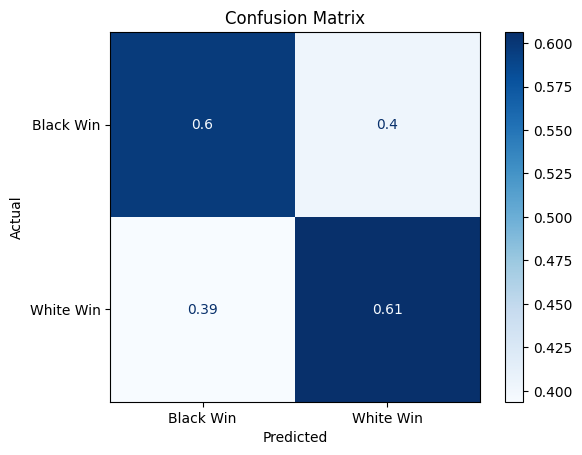

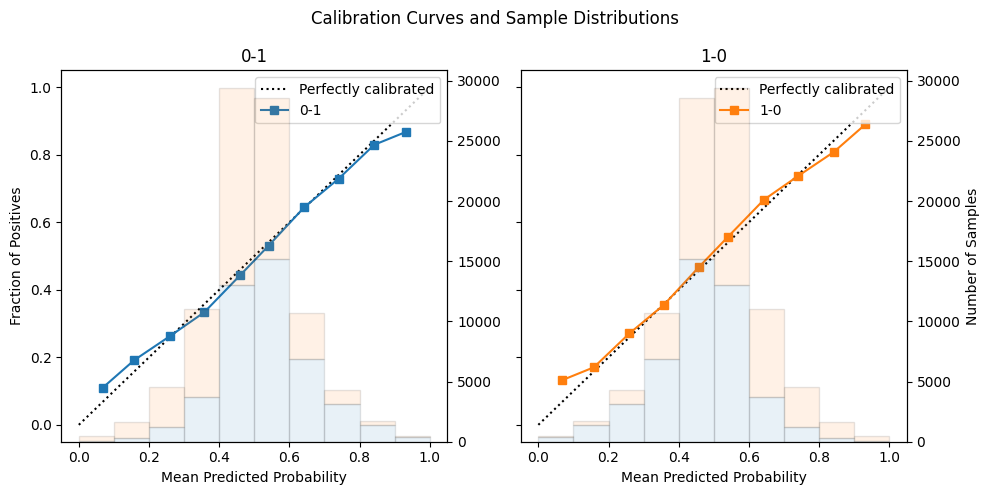

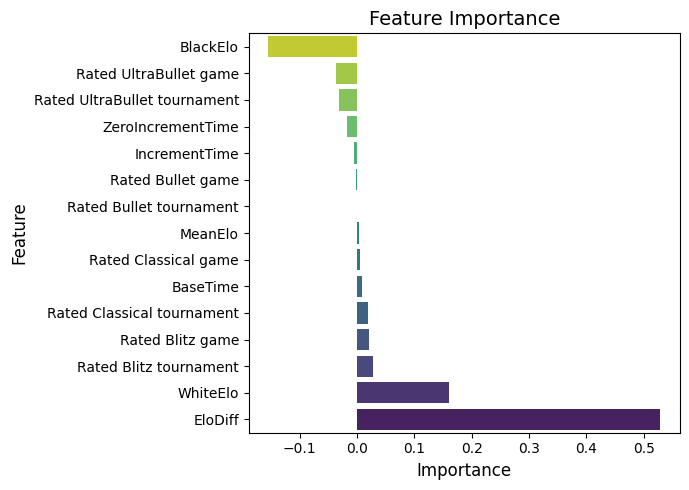

In [15]:
with mlflow.start_run(run_name="L2; no draws: LogiReg"):
    apply_logistic_regression(
        predict_draws=False, train=train_data, valid=valid_data, penalty="l2", tol=0.01
    )

#### Predicting Without Draws Using L2 Penalties

Log Loss on test data: 0.6562
Balanced Accuracy on test data: 60.14%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.60      0.60    378005              0.59      0.59      0.59     45215
         1-0       0.61      0.61      0.61    392248              0.61      0.61      0.61     47511
    accuracy                           0.60    770253                                  0.60     92726
   macro avg       0.60      0.60      0.60    770253              0.60      0.60      0.60     92726
weighted avg       0.60      0.60      0.60    770253              0.60      0.60      0.60     92726
       


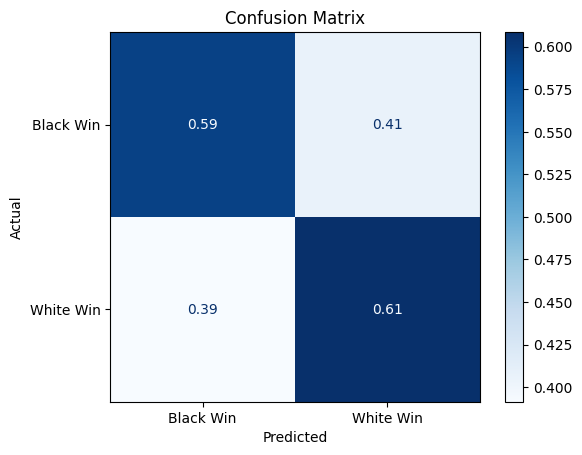

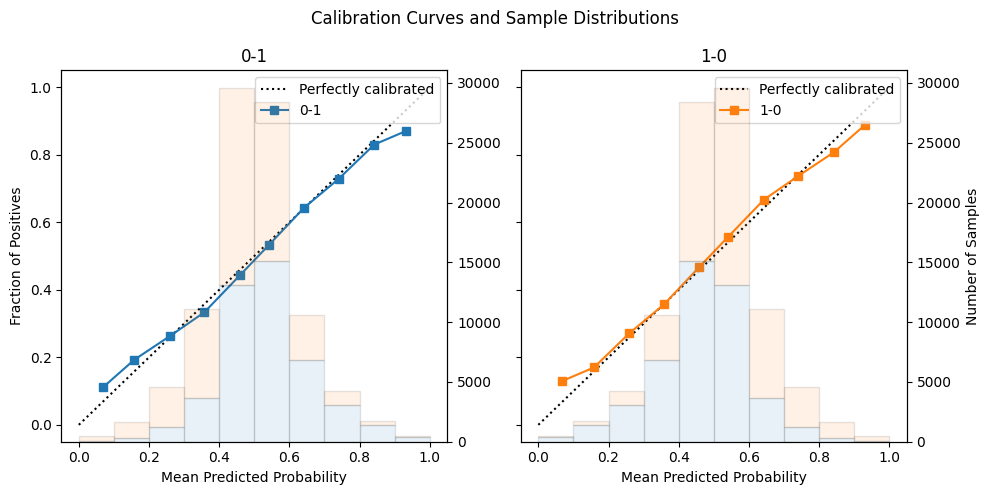

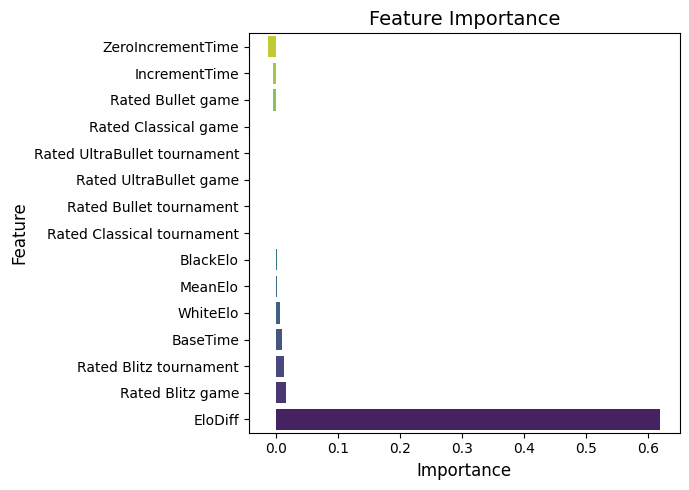

In [16]:
with mlflow.start_run(run_name="L1; no draws: LogiReg"):
    apply_logistic_regression(
        predict_draws=False, train=train_data, valid=valid_data, penalty="l1", tol=0.01
    )

Accuracy is close to naive prediction (around 60%). The most important feature is the difference in ELO, which is especially evident when using L1 penalty.


#### Predicting With Draws Using L2 Penalties

Log Loss on test data: 1.0381
Balanced Accuracy on test data: 46.56%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.42      0.49    378005              0.59      0.42      0.49     45215
         1-0       0.61      0.41      0.49    392248              0.61      0.41      0.49     47511
     1/2-1/2       0.04      0.57      0.08     20431              0.05      0.57      0.09      2537
    accuracy                           0.42    790684                                  0.42     95263
   macro avg       0.42      0.47      0.35    790684              0.42      0.47      0.36     95263
weighted avg       0.59      0.42      0.48    790684              0.59      0.42      0.48     95263
       


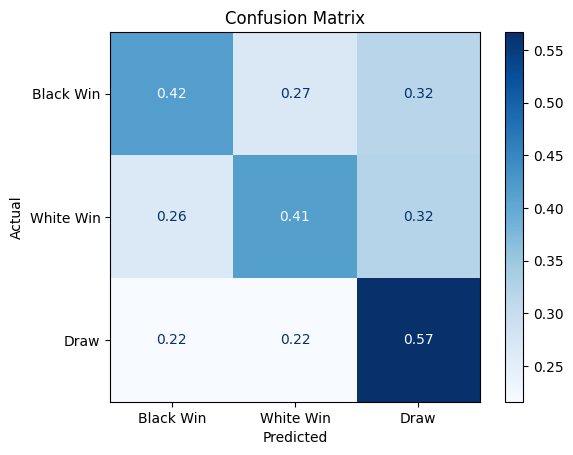

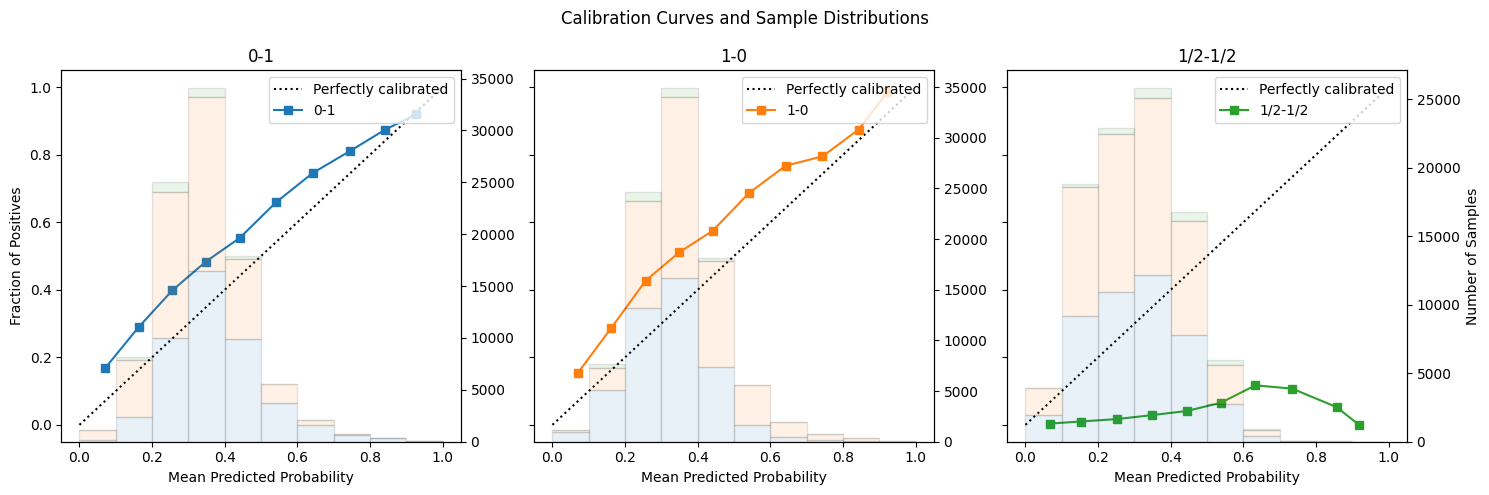

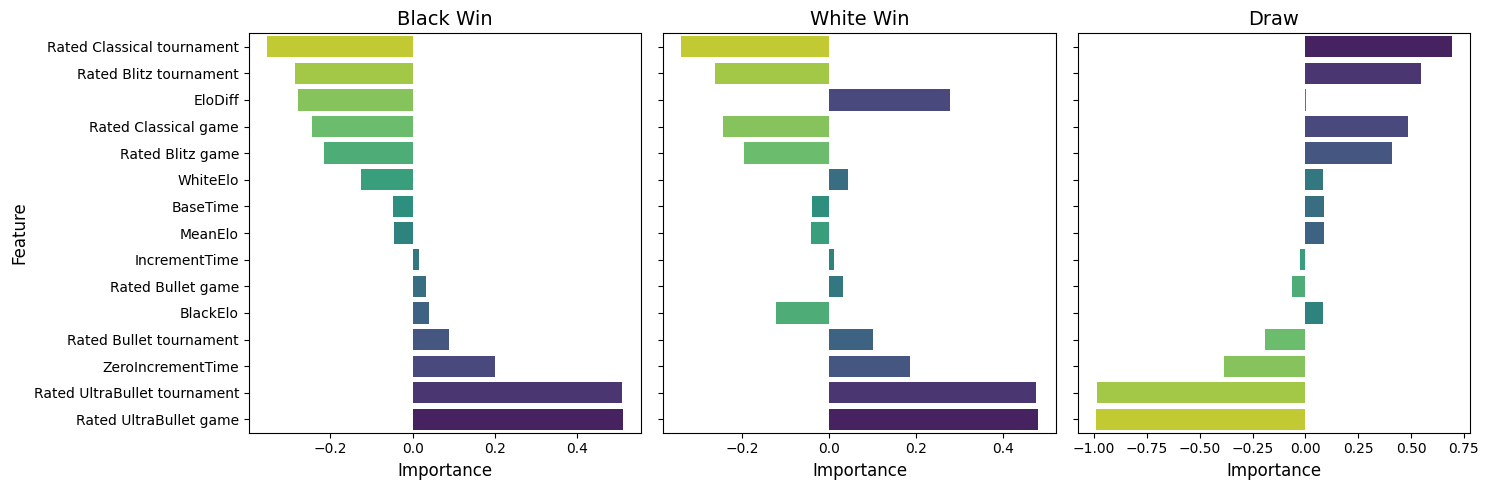

In [17]:
with mlflow.start_run(run_name="L2; predict draws: LogiReg"):
    apply_logistic_regression(
        predict_draws=True, train=train_data, valid=valid_data, penalty="l2", tol=0.01
    )

Of course, predicting draws has negatively impacted the overall picture: both recall and F1 score have dropped significantly. Draws have poor precision and F1 score, but quite decent recall.

It's also interesting to note, that the feature importance chart looks completely different here.


Log Loss on test data: 1.0381
Balanced Accuracy on test data: 46.6%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.42      0.49    378005              0.59      0.42      0.49     45215
         1-0       0.61      0.41      0.49    392248              0.61      0.42      0.49     47511
     1/2-1/2       0.04      0.57      0.08     20431              0.05      0.57      0.09      2537
    accuracy                           0.42    790684                                  0.42     95263
   macro avg       0.42      0.47      0.35    790684              0.42      0.47      0.36     95263
weighted avg       0.59      0.42      0.48    790684              0.59      0.42      0.48     95263
       


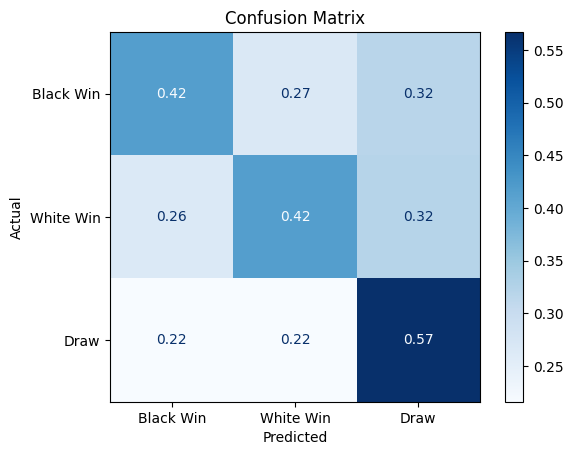

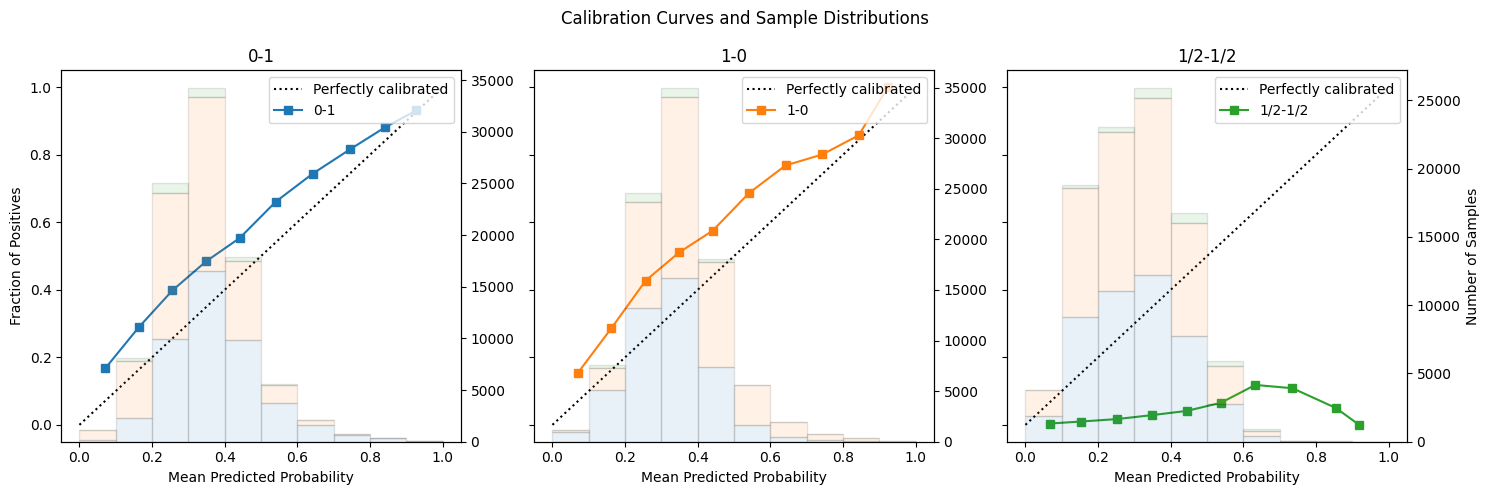

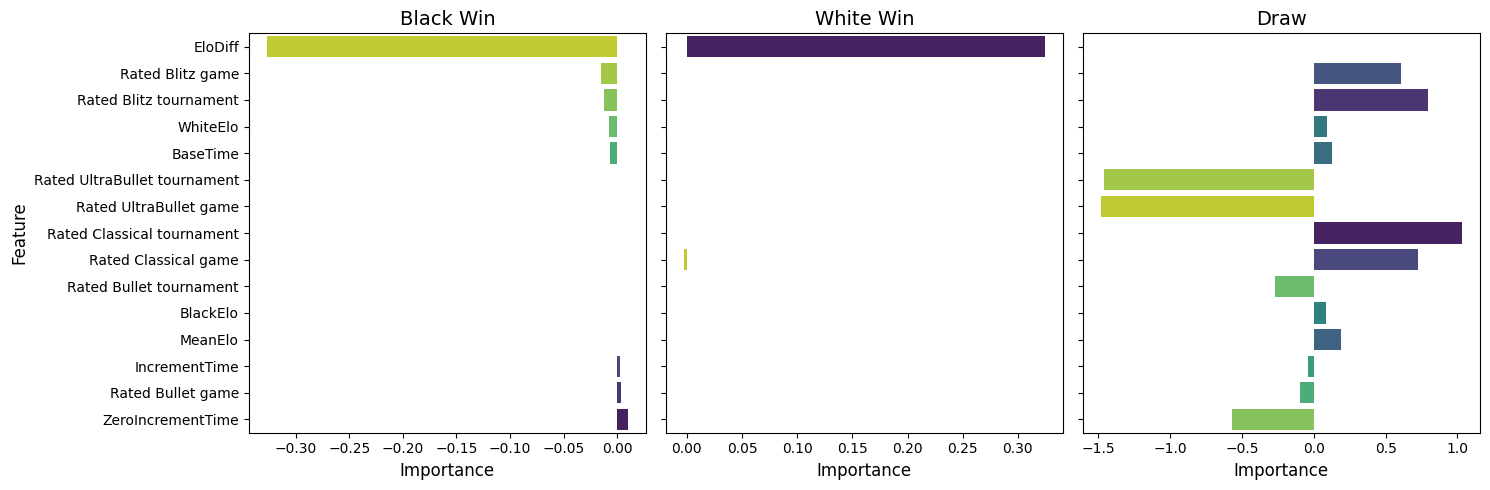

In [18]:
with mlflow.start_run(run_name="L1; predict draws: LogiReg"):
    apply_logistic_regression(
        predict_draws=True, train=train_data, valid=valid_data, penalty="l1", tol=0.008
    )

The L1 penalty moved EloDiff to the top position again. Interestingly, this did not affect the model's results. Both models have identical precision, recall, and F1 scores.


## Partial Feature Training

In [19]:
def implement_partial_feature_training(features_list, return_model=False):
    # features_list: with "Result" column
    model = apply_logistic_regression(
        predict_draws=True,
        train=train_data[features_list],
        valid=valid_data[features_list],
        test=test_data[features_list],
        penalty="l2",
        tol=0.01,
        c=1,
        return_model=return_model,
    )
    if return_model:
        return model

### "WhiteElo", "BlackElo", "MeanElo"

Log Loss on test data: 1.053
Balanced Accuracy on test data: 43.76%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.45      0.51    378005              0.59      0.44      0.50     45215
         1-0       0.61      0.44      0.51    392248              0.61      0.45      0.51     47511
     1/2-1/2       0.04      0.42      0.07     20431              0.04      0.43      0.07      2537
    accuracy                           0.44    790684                                  0.44     95263
   macro avg       0.41      0.44      0.36    790684              0.41      0.44      0.36     95263
weighted avg       0.59      0.44      0.50    790684              0.58      0.44      0.50     95263
       


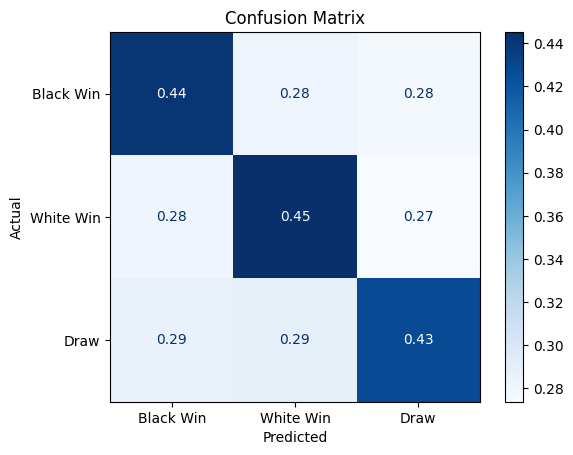

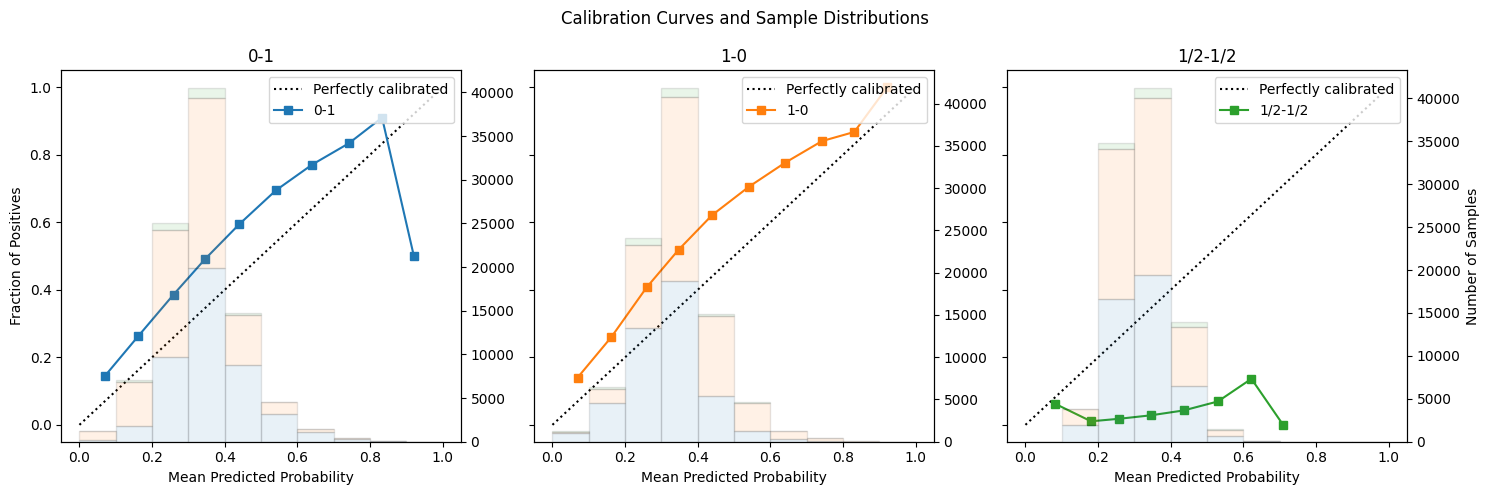

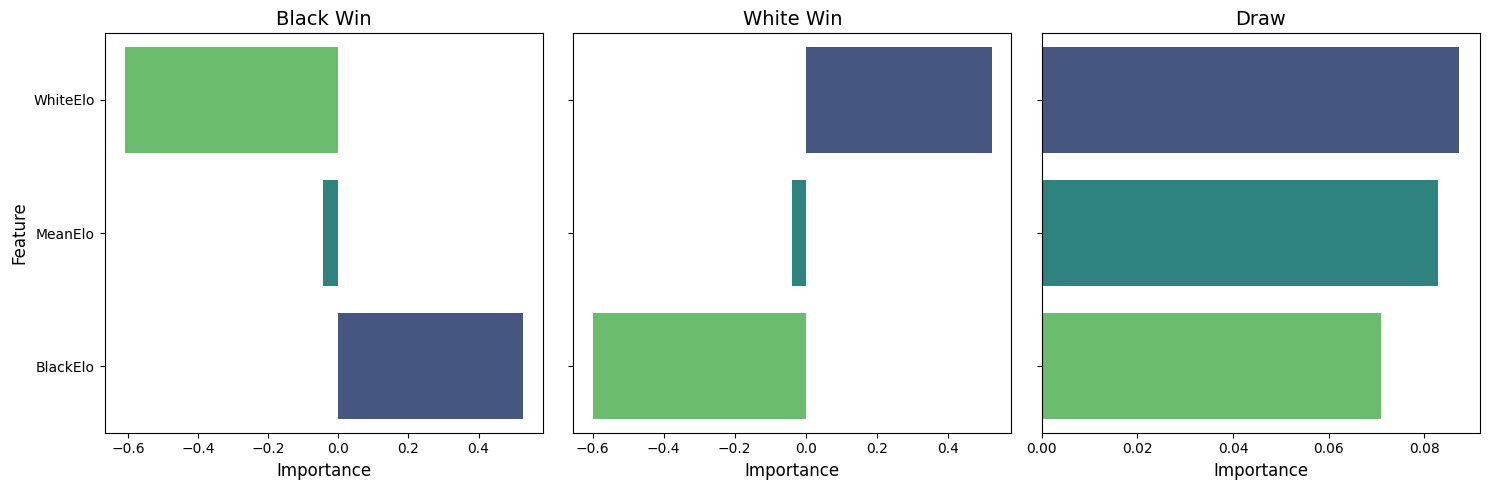

In [20]:
implement_partial_feature_training(
    features_list=["WhiteElo", "BlackElo", "MeanElo", "Result"]
)

### "MeanElo" and "EloDiff"

Log Loss on test data: 1.0541
Balanced Accuracy on test data: 43.79%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.44      0.51    378005              0.59      0.44      0.50     45215
         1-0       0.61      0.44      0.51    392248              0.61      0.44      0.51     47511
     1/2-1/2       0.04      0.43      0.07     20431              0.04      0.43      0.07      2537
    accuracy                           0.44    790684                                  0.44     95263
   macro avg       0.41      0.44      0.36    790684              0.41      0.44      0.36     95263
weighted avg       0.59      0.44      0.50    790684              0.58      0.44      0.50     95263
       


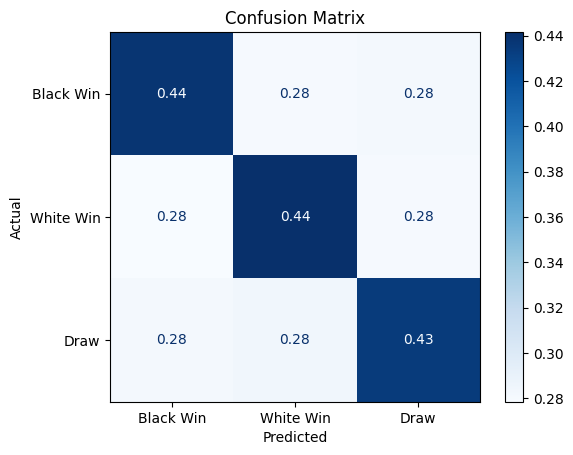

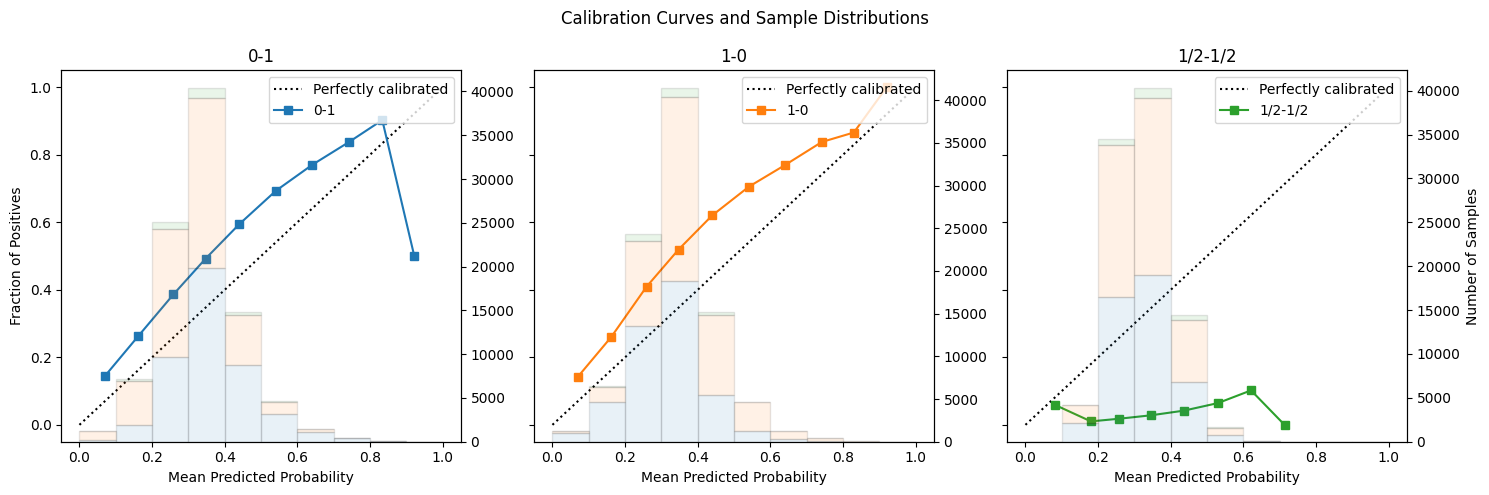

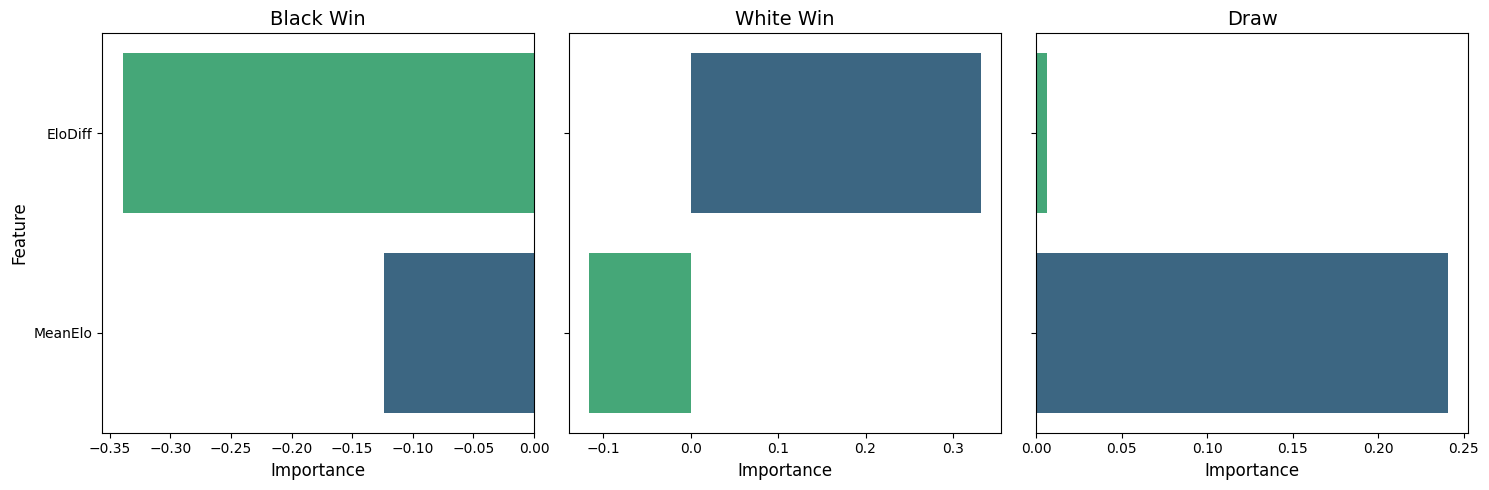

In [21]:
implement_partial_feature_training(features_list=["MeanElo", "EloDiff", "Result"])

### "EloDiff", "MeanElo", "ZeroIncrementTime"

Log Loss on test data: 1.0476
Balanced Accuracy on test data: 45.52%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.44      0.50    378005              0.59      0.44      0.50     45215
         1-0       0.61      0.43      0.51    392248              0.61      0.44      0.51     47511
     1/2-1/2       0.04      0.48      0.08     20431              0.05      0.49      0.08      2537
    accuracy                           0.44    790684                                  0.44     95263
   macro avg       0.41      0.45      0.36    790684              0.41      0.46      0.36     95263
weighted avg       0.59      0.44      0.49    790684              0.58      0.44      0.49     95263
       


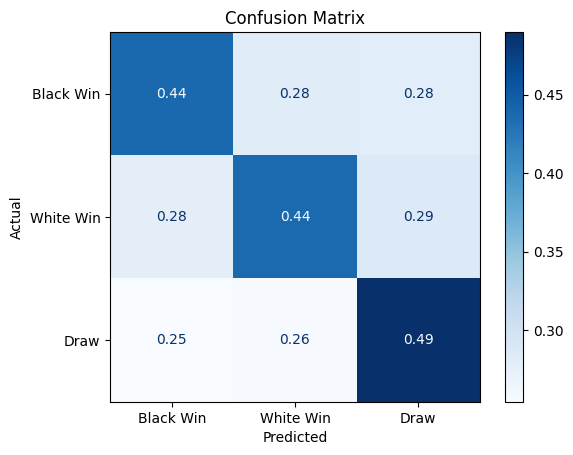

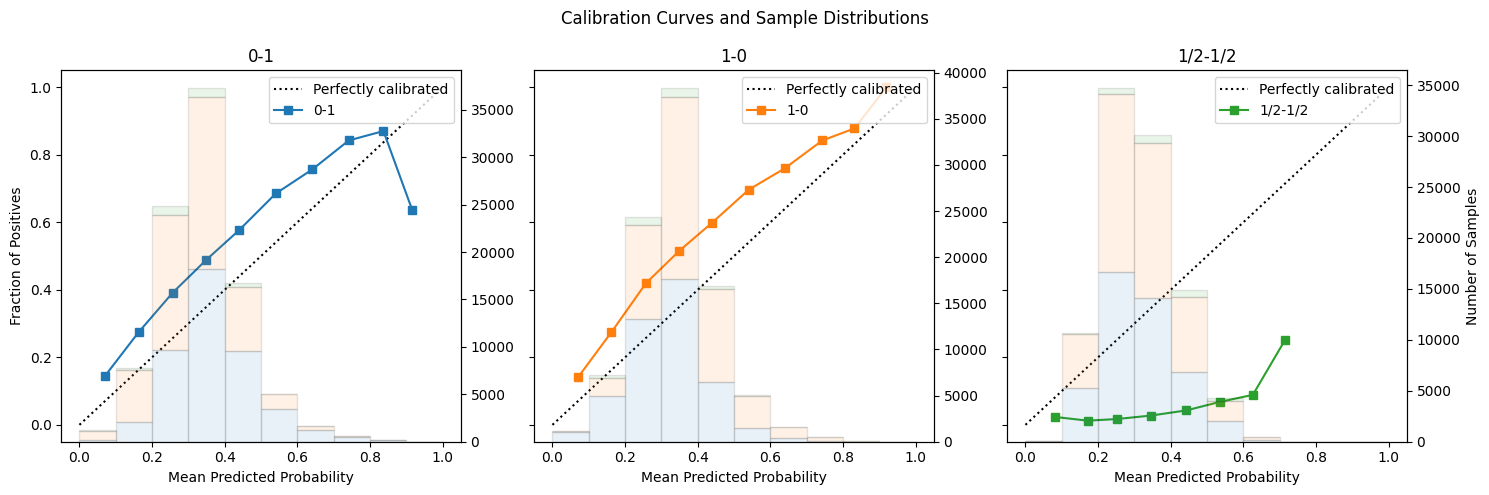

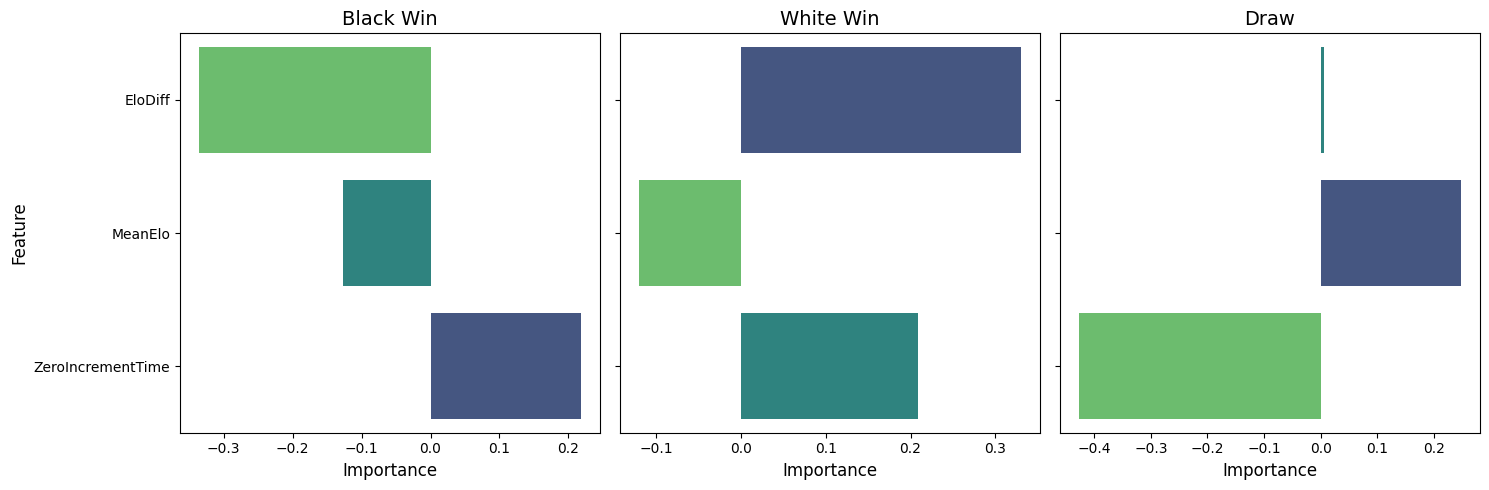

In [22]:
implement_partial_feature_training(
    features_list=["EloDiff", "MeanElo", "ZeroIncrementTime", "Result"]
)

### All Features Except "BlackElo", "WhiteElo", "IncrementTime", "BaseTime"

Log Loss on test data: 1.0412
Balanced Accuracy on test data: 46.53%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.42      0.49    378005              0.59      0.41      0.49     45215
         1-0       0.61      0.40      0.49    392248              0.61      0.41      0.49     47511
     1/2-1/2       0.04      0.57      0.08     20431              0.05      0.58      0.08      2537
    accuracy                           0.41    790684                                  0.41     95263
   macro avg       0.42      0.46      0.35    790684              0.42      0.47      0.35     95263
weighted avg       0.59      0.41      0.48    790684              0.59      0.41      0.48     95263
       


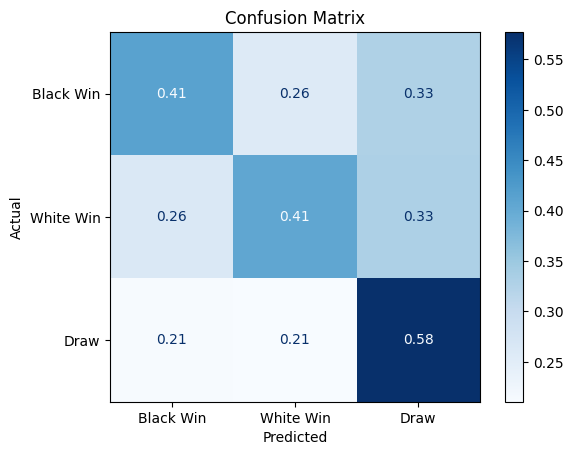

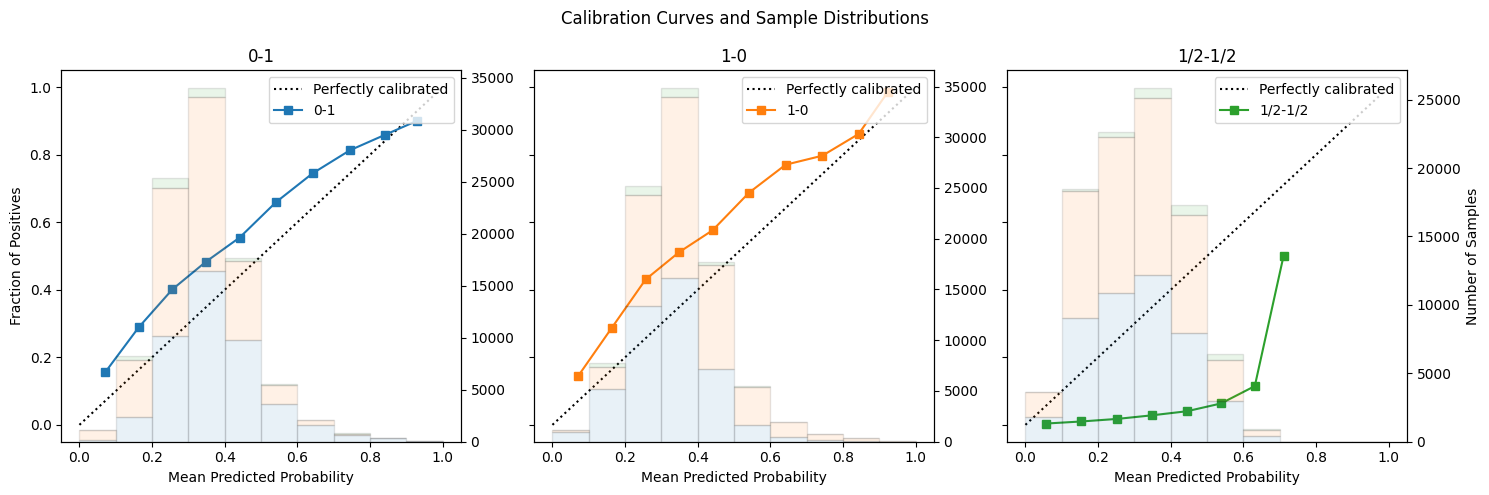

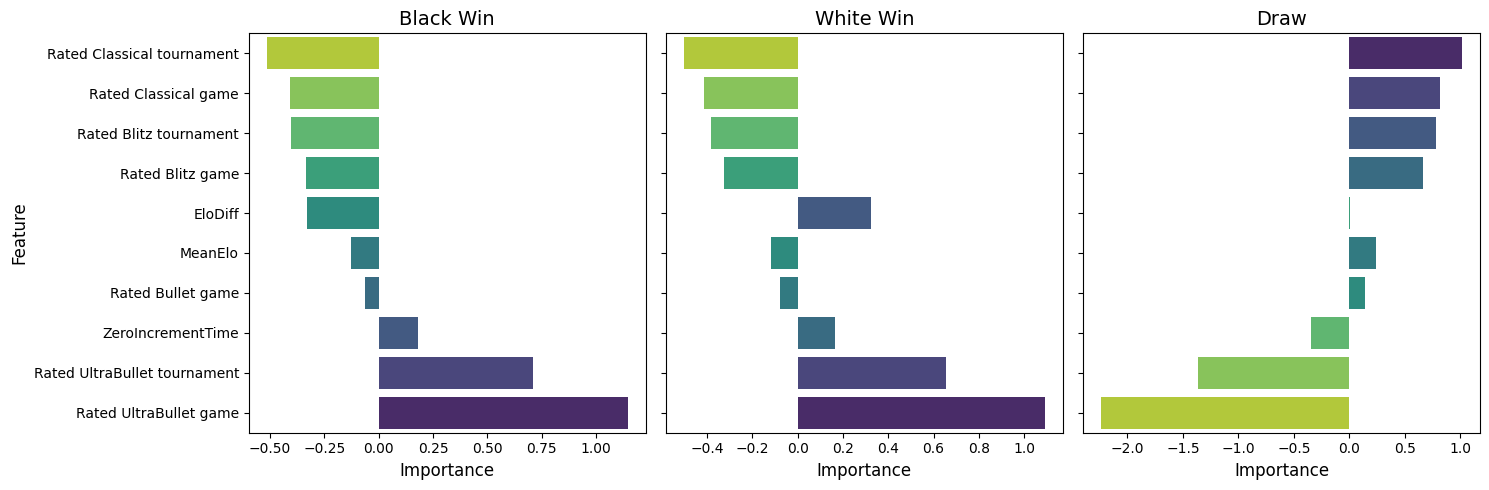

In [23]:
features = train_data.columns.drop(
    ["BlackElo", "WhiteElo", "IncrementTime", "BaseTime", "Rated Bullet tournament"]
)
log_reg_model = implement_partial_feature_training(
    features_list=features, return_model=True
)

## Zero Coefficients
Lets set all coefficients to zero except EloDiff. Also I need to reset the intercept.

In [24]:
def zero_coefficients(model, features_list):
    model.coef_[0:2, 1:] = 0
    model.intercept_[2] = -0.17

    X_train, y_train = get_x_and_y(train_data[features_list], predict_draws=True)
    X_valid, y_valid = get_x_and_y(valid_data[features_list], predict_draws=True)

    estimate_baseline_model(model, model.coef_, X_train, y_train, X_valid, y_valid)

Log Loss on test data: 1.0485
Balanced Accuracy on test data: 46.48%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.60      0.41      0.49    378005              0.60      0.41      0.48     45215
         1-0       0.61      0.42      0.50    392248              0.61      0.43      0.50     47511
     1/2-1/2       0.04      0.56      0.08     20431              0.05      0.56      0.08      2537
    accuracy                           0.42    790684                                  0.42     95263
   macro avg       0.42      0.46      0.36    790684              0.42      0.46      0.36     95263
weighted avg       0.59      0.42      0.48    790684              0.59      0.42      0.48     95263
       


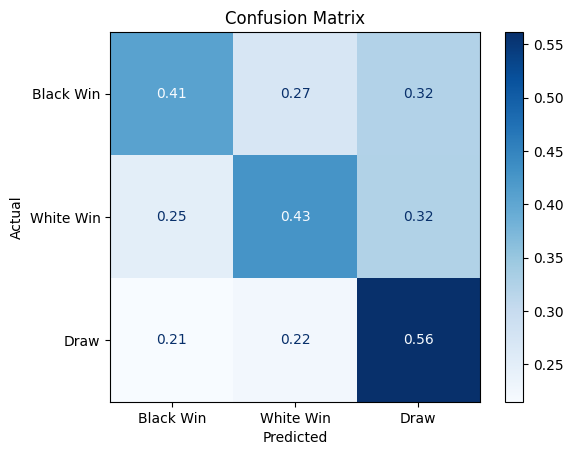

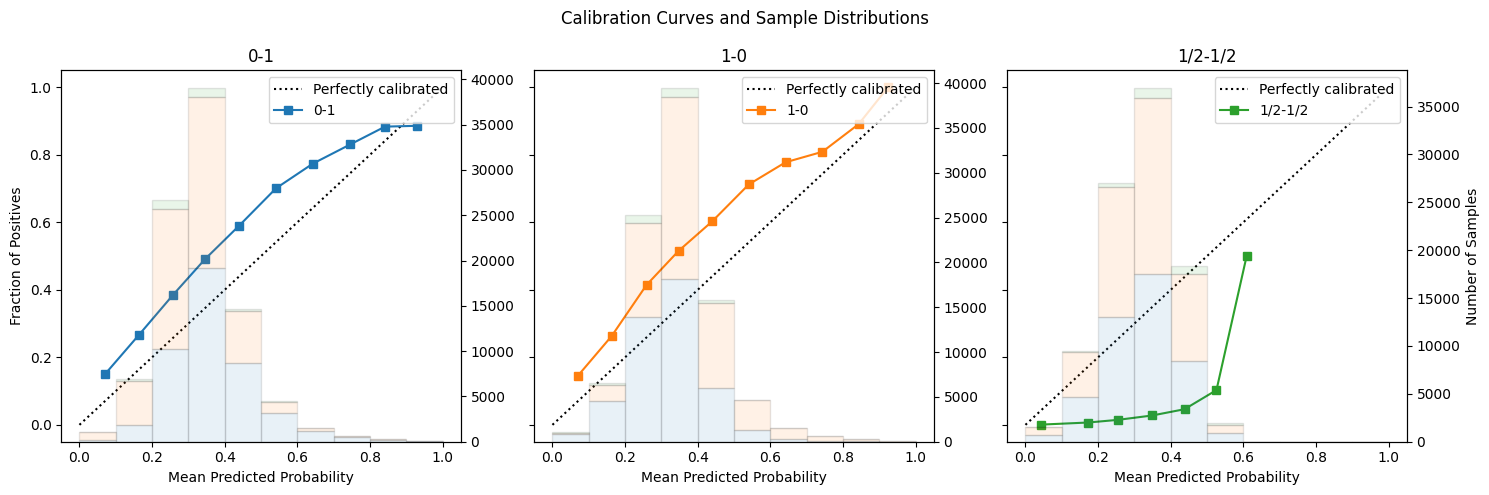

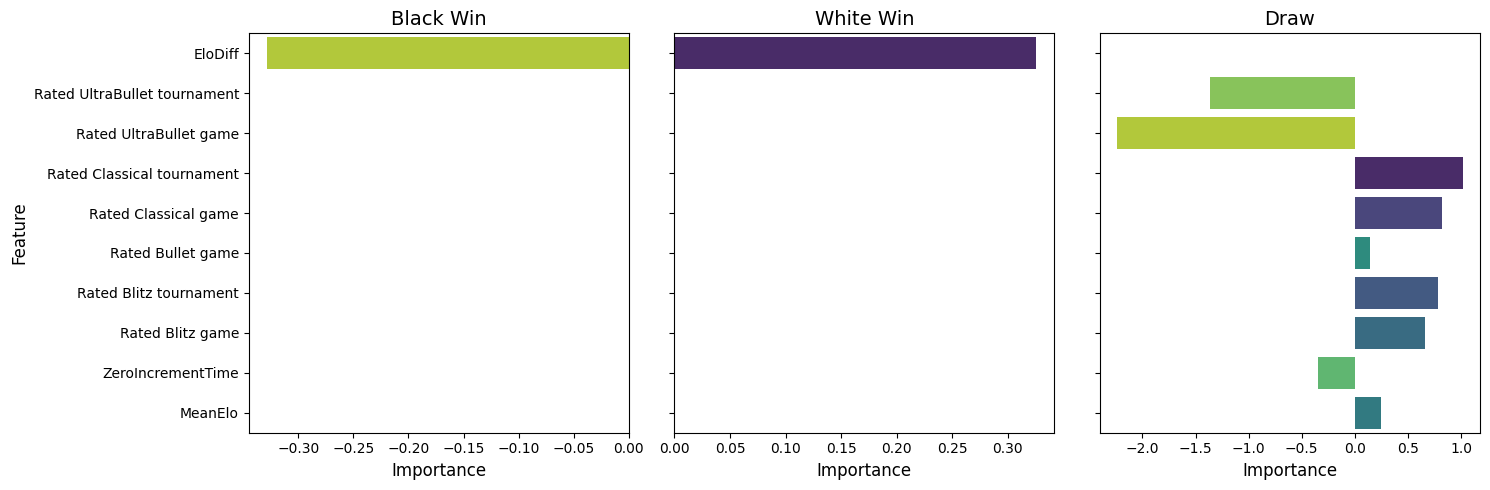

In [25]:
zero_coefficients(log_reg_model, features)

Well, I achieved the same results as before: 46.53% vs. 46.48% balanced accuracy on the test set. This means the hypothesis that only EloDiff affects the prediction of a win is correct. The other features only influence the prediction of a draw.

### Summary

* All models have matching metrics on both the train and validation sets, indicating that the models are underfitting.
* EloDiff has the most significant impact on predicting a win, which explains the strong performance of the naive model when draws are not considered: 60.09%.
* For predicting draws, the recall is decent (0.57), but the precision is low (0.05). However, the balanced accuracy of the logistic regression model is higher than that of the naive model (46.6% vs. 40.06%).

**Conclusion:** If the dataset has a low percentage of draws (for example, blitz games with short time controls, like 30 seconds), it makes sense to ignore draws and use the naive model.   
However, if the dataset contains a high number of draws, it's better to use logistic regression, as it has a good recall for predicting draws.